In [2]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\anaconda\lib\site-packages (2.1.4)



In [1]:
import pandas as pd
df = pd.read_excel('FEV-data-Excel.xlsx')

In [2]:
df.head()

,Car full name,Make,Model,Minimal price (gross) [PLN],Engine power [KM],Maximum torque [Nm],Type of brakes,Drive type,Battery capacity [kWh],Range (WLTP) [km],...,Permissable gross weight [kg],Maximum load capacity [kg],Number of seats,Number of doors,Tire size [in],Maximum speed [kph],Boot capacity (VDA) [l],Acceleration 0-100 kph [s],Maximum DC charging power [kW],mean - Energy consumption [kWh/100 km]
0,Audi e-tron 55 quattro,Audi,e-tron 55 quattro,345700,360,664,disc (front + rear),4WD,95.0,438,...,3130.0,640.0,5,5,19,200,660.0,5.7,150,24.45
1,Audi e-tron 50 quattro,Audi,e-tron 50 quattro,308400,313,540,disc (front + rear),4WD,71.0,340,...,3040.0,670.0,5,5,19,190,660.0,6.8,150,23.80
2,Audi e-tron S quattro,Audi,e-tron S quattro,414900,503,973,disc (front + rear),4WD,95.0,364,...,3130.0,565.0,5,5,20,210,660.0,4.5,150,27.55
3,Audi e-tron Sportback 50 quattro,Audi,e-tron Sportback 50 quattro,319700,313,540,disc (front + rear),4WD,71.0,346,...,3040.0,640.0,5,5,19,190,615.0,6.8,150,23.30
4,Audi e-tron Sportback 55 quattro,Audi,e-tron Sportback 55 quattro,357000,360,664,disc (front + rear),4WD,95.0,447,...,3130.0,670.0,5,5,19,200,615.0,5.7,150,23.85


In [3]:
#TASK 1

import pandas as pd

try:
    df = pd.read_excel('FEV-data-Excel.xlsx')
except FileNotFoundError:
    print("Error: The file 'FEV-data-Excel.xlsx' was not found. Please check the file path.")

filtered_evs = df[(df['Minimal price (gross) [PLN]'] <= 350000) & (df['Range (WLTP) [km]'] >= 400)]

print("--- Filtered EVs (meeting the budget and range criteria) ---")
print(filtered_evs[['Car full name', 'Minimal price (gross) [PLN]', 'Range (WLTP) [km]']])
print("\n" + "="*50 + "\n")


grouped_by_make = filtered_evs.groupby('Make')

average_battery_capacity = grouped_by_make['Battery capacity [kWh]'].mean()

print("--- Average Battery Capacity per Manufacturer (for filtered EVs) ---")
print(average_battery_capacity)

--- Filtered EVs (meeting the budget and range criteria) ---
                        Car full name  Minimal price (gross) [PLN]  \
0              Audi e-tron 55 quattro                       345700   
8                             BMW iX3                       282900   
15        Hyundai Kona electric 64kWh                       178400   
18                   Kia e-Niro 64kWh                       167990   
20                   Kia e-Soul 64kWh                       160990   
22                  Mercedes-Benz EQC                       334700   
39  Tesla Model 3 Standard Range Plus                       195490   
40           Tesla Model 3 Long Range                       235490   
41          Tesla Model 3 Performance                       260490   
47    Volkswagen ID.3 Pro Performance                       155890   
48              Volkswagen ID.3 Pro S                       179990   
49                Volkswagen ID.4 1st                       202390   

    Range (WLTP) [km]  
0   

In [1]:

print(df.columns)

Index(['Car full name', 'Make', 'Model', 'Minimal price (gross) [PLN]',
       'Engine power [KM]', 'Maximum torque [Nm]', 'Type of brakes',
       'Drive type', 'Battery capacity [kWh]', 'Range (WLTP) [km]',
       'Wheelbase [cm]', 'Length [cm]', 'Width [cm]', 'Height [cm]',
       'Minimal empty weight [kg]', 'Permissable gross weight [kg]',
       'Maximum load capacity [kg]', 'Number of seats', 'Number of doors',
       'Tire size [in]', 'Maximum speed [kph]', 'Boot capacity (VDA) [l]',
       'Acceleration 0-100 kph [s]', 'Maximum DC charging power [kW]',
       'mean - Energy consumption [kWh/100 km]'],
      dtype='object')


In [9]:
#TASK 2
try:
    energy_consumption = df['mean - Energy consumption [kWh/100 km]']

except KeyError:
    print("\n--- Column Not Found ---")
else:
    Q1 = energy_consumption.quantile(0.25)
    Q3 = energy_consumption.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(energy_consumption < lower_bound) | (energy_consumption > upper_bound)]

    print("\n--- Outliers in Mean Energy Consumption ---")
    print(f"Q1 (25th percentile): {Q1:.2f} kWh/100 km")
    print(f"Q3 (75th percentile): {Q3:.2f} kWh/100 km")
    print(f"IQR: {IQR:.2f} kWh/100 km")
    print(f"Lower Bound: {lower_bound:.2f} kWh/100 km")
    print(f"Upper Bound: {upper_bound:.2f} kWh/100 km")

    print("\nVehicles identified as outliers:")
    if not outliers.empty:
        print(outliers[['Car full name', 'mean - Energy consumption [kWh/100 km]']])
    else:
        print("No outliers found.")


--- Outliers in Mean Energy Consumption ---
Q1 (25th percentile): 15.60 kWh/100 km
Q3 (75th percentile): 23.50 kWh/100 km
IQR: 7.90 kWh/100 km
Lower Bound: 3.75 kWh/100 km
Upper Bound: 35.35 kWh/100 km

Vehicles identified as outliers:
No outliers found.


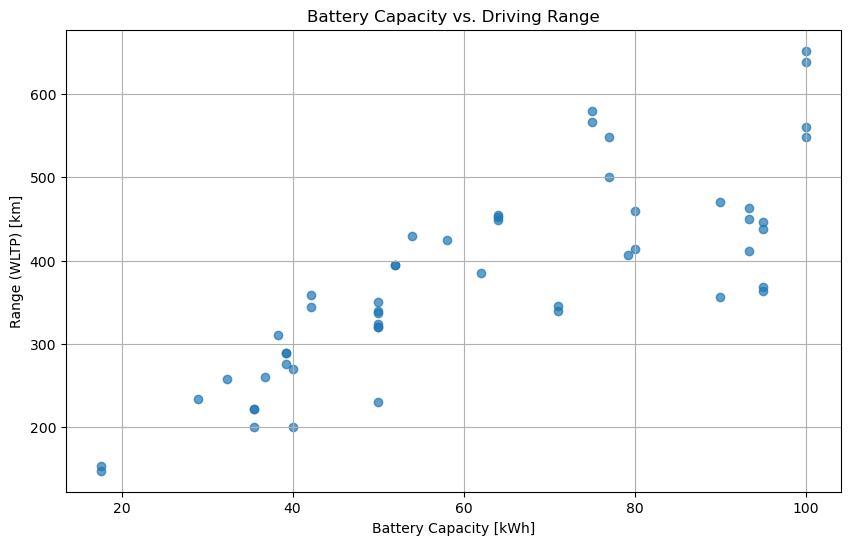

In [10]:
#TASK 3

import matplotlib.pyplot as plt

try:
    df = pd.read_excel('FEV-data-Excel.xlsx')
except FileNotFoundError:
    print("Error: The file 'FEV-data-Excel.xlsx' was not found. Please check the file path.")

plt.figure(figsize=(10, 6))
plt.scatter(df['Battery capacity [kWh]'], df['Range (WLTP) [km]'], alpha=0.7)
plt.title('Battery Capacity vs. Driving Range')
plt.xlabel('Battery Capacity [kWh]')
plt.ylabel('Range (WLTP) [km]')
plt.grid(True)
plt.show()

In [16]:
#TASK 4

try:
    df = pd.read_excel('FEV-data-Excel.xlsx')
except FileNotFoundError:
    print("Error: The file 'FEV-data-Excel.xlsx' was not found. Please check the file path.")

class EVRecommender:
   
    def __init__(self, dataframe):
        self.df = dataframe

    def recommend_evs(self, budget, desired_range, battery_capacity):
       
       
        matching_evs = self.df[
            (self.df['Minimal price (gross) [PLN]'] <= budget) &
            (self.df['Range (WLTP) [km]'] >= desired_range) &
            (self.df['Battery capacity [kWh]'] >= battery_capacity)
            ].copy()
        matching_evs.sort_values(by='Minimal price (gross) [PLN]', inplace=True)
        
       
        if not matching_evs.empty:
            return matching_evs.head(3)
        else:
            return pd.DataFrame()


ev_recommender = EVRecommender(df)

customer_budget = 350000
customer_range = 400
customer_battery = 60

recommendations = ev_recommender.recommend_evs(
    budget=customer_budget,
    desired_range=customer_range,
    battery_capacity=customer_battery
)

print("\n--- Top 3 EV Recommendations ---")
if not recommendations.empty:
    print(recommendations[['Car full name', 'Minimal price (gross) [PLN]', 'Range (WLTP) [km]', 'Battery capacity [kWh]']])
else:
    print("No EVs match the specified criteria. Please adjust your search.")


--- Top 3 EV Recommendations ---
                  Car full name  Minimal price (gross) [PLN]  \
20             Kia e-Soul 64kWh                       160990   
18             Kia e-Niro 64kWh                       167990   
15  Hyundai Kona electric 64kWh                       178400   

    Range (WLTP) [km]  Battery capacity [kWh]  
20                452                    64.0  
18                455                    64.0  
15                449                    64.0  


In [14]:
#TASK 5

from scipy import stats

try:
    df = pd.read_excel('FEV-data-Excel.xlsx')
except FileNotFoundError:
    print("Error: The file 'FEV-data-Excel.xlsx' was not found. Please check the file path.")

# Filter the DataFrame to get the engine power for Tesla and Audi
tesla_power = df[df['Make'] == 'Tesla']['Engine power [KM]']
audi_power = df[df['Make'] == 'Audi']['Engine power [KM]']

t_statistic, p_value = stats.ttest_ind(tesla_power, audi_power, nan_policy='omit')

print("--- Two-Sample T-Test Results ---")
print(f"Mean Engine Power (Tesla): {tesla_power.mean():.2f} KM")
print(f"Mean Engine Power (Audi): {audi_power.mean():.2f} KM")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.8f}")

alpha = 0.05
print("\n--- Conclusion ---")
if p_value < alpha:
    print(f"Since the p-value ({p_value:.8f}) is less than the significance level of {alpha},")
    print("we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in the average engine power between Tesla and Audi vehicles.")
else:
    print(f"Since the p-value ({p_value:.8f}) is greater than the significance level of {alpha},")
    print("we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in the average engine power between Tesla and Audi vehicles.")

--- Two-Sample T-Test Results ---
Mean Engine Power (Tesla): 533.00 KM
Mean Engine Power (Audi): 392.00 KM
T-statistic: 1.7024
P-value: 0.11672693

--- Conclusion ---
Since the p-value (0.11672693) is greater than the significance level of 0.05,
we fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference in the average engine power between Tesla and Audi vehicles.
